In [ ]:
# --- Holt vs Holt-Winters Example for Seasonal Sales/Passengers Forecasting ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import ExponentialSmoothing



In [ ]:
# -----------------------------------------------------------
# 1. Generate seasonal synthetic data
# -----------------------------------------------------------
np.random.seed(123)
periods = 60   # 5 years of monthly data
time = np.arange(periods)
trend = 200 + 2 * time                           # upward trend
seasonal = 20 * np.sin(2 * np.pi * time / 12)    # yearly seasonality
noise = np.random.normal(0, 10, size=periods)
sales = trend + seasonal + noise

data = pd.DataFrame({
    "Month": pd.date_range("2018-01-01", periods=periods, freq="M"),
    "Sales": sales
})
data.set_index("Month", inplace=True)




/tmp/ipython-input-3411893290.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  "Month": pd.date_range("2018-01-01", periods=periods, freq="M"),


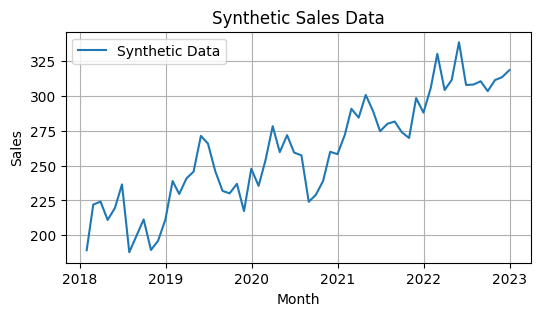

In [ ]:
# -----------------------------------------------------------
# Plot synthetic data
# -----------------------------------------------------------
plt.figure(figsize=(6, 3))
plt.plot(data.index, data["Sales"], label="Synthetic Data")
plt.title("Synthetic Sales Data")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# -----------------------------------------------------------
# 2. Split into train and test
# -----------------------------------------------------------
train = data.iloc[:-12]
test = data.iloc[-12:]




In [ ]:
# -----------------------------------------------------------
# 3. Holt’s Linear Trend Model (no seasonality)
# -----------------------------------------------------------
holt_model = ExponentialSmoothing(train["Sales"],
                                  trend="add",
                                  seasonal=None).fit(optimized=True)
holt_forecast = holt_model.forecast(12)



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [ ]:
# -----------------------------------------------------------
# 4. Holt-Winters Seasonal Model (additive seasonality)
# -----------------------------------------------------------
hw_model = ExponentialSmoothing(train["Sales"],
                                trend="add",
                                seasonal="add",
                                seasonal_periods=12).fit(optimized=True)
hw_forecast = hw_model.forecast(12)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [ ]:


# -----------------------------------------------------------
# 5. Combine into a single DataFrame
# -----------------------------------------------------------
results = pd.DataFrame({
    "Actual": test["Sales"],
    "Holt": holt_forecast,
    "Holt_Winters": hw_forecast
})
print(results.round(2))



            Actual    Holt  Holt_Winters
2022-01-31  305.79  291.67        293.18
2022-02-28  330.38  293.63        308.32
2022-03-31  304.38  295.59        316.28
2022-04-30  311.61  297.55        313.58
2022-05-31  338.76  299.51        322.32
2022-06-30  308.02  301.47        318.42
2022-07-31  308.30  303.43        302.12
2022-08-31  310.69  305.39        293.63
2022-09-30  303.59  307.35        295.40
2022-10-31  311.55  309.31        293.08
2022-11-30  313.64  311.28        302.24
2022-12-31  318.69  313.24        310.60


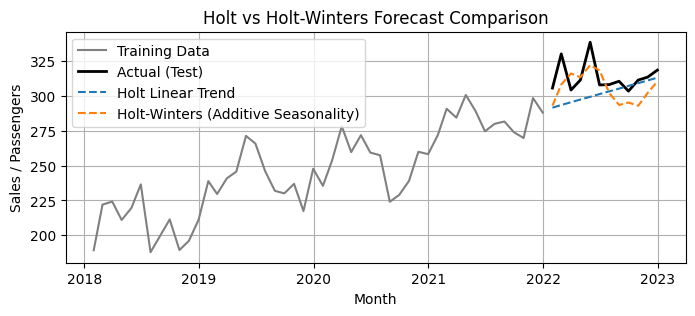

In [ ]:
# -----------------------------------------------------------
# 6. Plot comparison
# -----------------------------------------------------------
plt.figure(figsize=(8,3))
plt.plot(train.index, train["Sales"], label="Training Data", color="gray")
plt.plot(test.index, test["Sales"], label="Actual (Test)", color="black", linewidth=2)
plt.plot(holt_forecast.index, holt_forecast, "--", label="Holt Linear Trend")
plt.plot(hw_forecast.index, hw_forecast, "--", label="Holt-Winters (Additive Seasonality)")
plt.title("Holt vs Holt-Winters Forecast Comparison")
plt.xlabel("Month")
plt.ylabel("Sales / Passengers")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# -----------------------------------------------------------
# 7. Evaluate forecast accuracy
# -----------------------------------------------------------
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_holt = mean_absolute_error(test["Sales"], holt_forecast)
rmse_holt = np.sqrt(mean_squared_error(test["Sales"], holt_forecast))

mae_hw = mean_absolute_error(test["Sales"], hw_forecast)
rmse_hw = np.sqrt(mean_squared_error(test["Sales"], hw_forecast))

print("Holt's Linear Trend Model:")
print(f"  MAE: {mae_holt:.2f}")
print(f"  RMSE: {rmse_holt:.2f}")
print("\nHolt-Winters Seasonal Model:")
print(f"  MAE: {mae_hw:.2f}")
print(f"  RMSE: {rmse_hw:.2f}")

Holt's Linear Trend Model:
  MAE: 11.96
  RMSE: 17.11

Holt-Winters Seasonal Model:
  MAE: 12.06
  RMSE: 13.24
